In [1]:
import matplotlib.pyplot as plt
import pandas as pd

In [ ]:
sz = "124M"

loss_baseline = {
    "124M": 3.2924,
}[sz]
hella2_baseline = {
    "124M": 0.294463,
    "350M": 0.375224,
    "774M": 0.431986,
    "1558M": 0.488946,
}[sz]

with open('./log/log.txt', 'r') as file:
    lines = file.readlines()

scores = {}
for line in lines:
    ep, mode, val = line.strip().split()
    scores[mode] = scores.get(mode, {})
    scores[mode][int(ep)] = float(val)

scores_xy = {}
for k, v in scores.items():
   xy = sorted(list(v.items()))
   scores_xy[k] = list(zip(*xy))

{'val': [(0,
   100,
   200,
   300,
   400,
   500,
   600,
   700,
   800,
   900,
   1000,
   1100,
   1200,
   1300,
   1400,
   1500,
   1600,
   1700,
   1800,
   1900,
   2000,
   2100,
   2200,
   2300,
   2400,
   2500,
   2600,
   2700,
   2800,
   2900,
   3000,
   3100,
   3200,
   3300,
   3400,
   3500,
   3600,
   3700,
   3800,
   3900,
   4000,
   4100,
   4200,
   4300,
   4400,
   4500,
   4600,
   4700,
   4800,
   4900,
   4999),
  (10.9499,
   6.5711,
   5.9333,
   5.4978,
   5.1041,
   4.7618,
   4.523,
   4.2986,
   4.1362,
   4.0144,
   3.9351,
   3.8714,
   3.8192,
   3.766,
   3.7325,
   3.6885,
   3.6545,
   3.6319,
   3.6014,
   3.5899,
   3.5605,
   3.5401,
   3.524,
   3.4989,
   3.4868,
   3.4746,
   3.4603,
   3.4441,
   3.4307,
   3.4178,
   3.4047,
   3.3916,
   3.3833,
   3.3723,
   3.3675,
   3.3599,
   3.3474,
   3.341,
   3.3317,
   3.3254,
   3.3178,
   3.3131,
   3.309,
   3.302,
   3.2975,
   3.2954,
   3.288,
   3.2864,
   3.2854,
   3.2831,
 

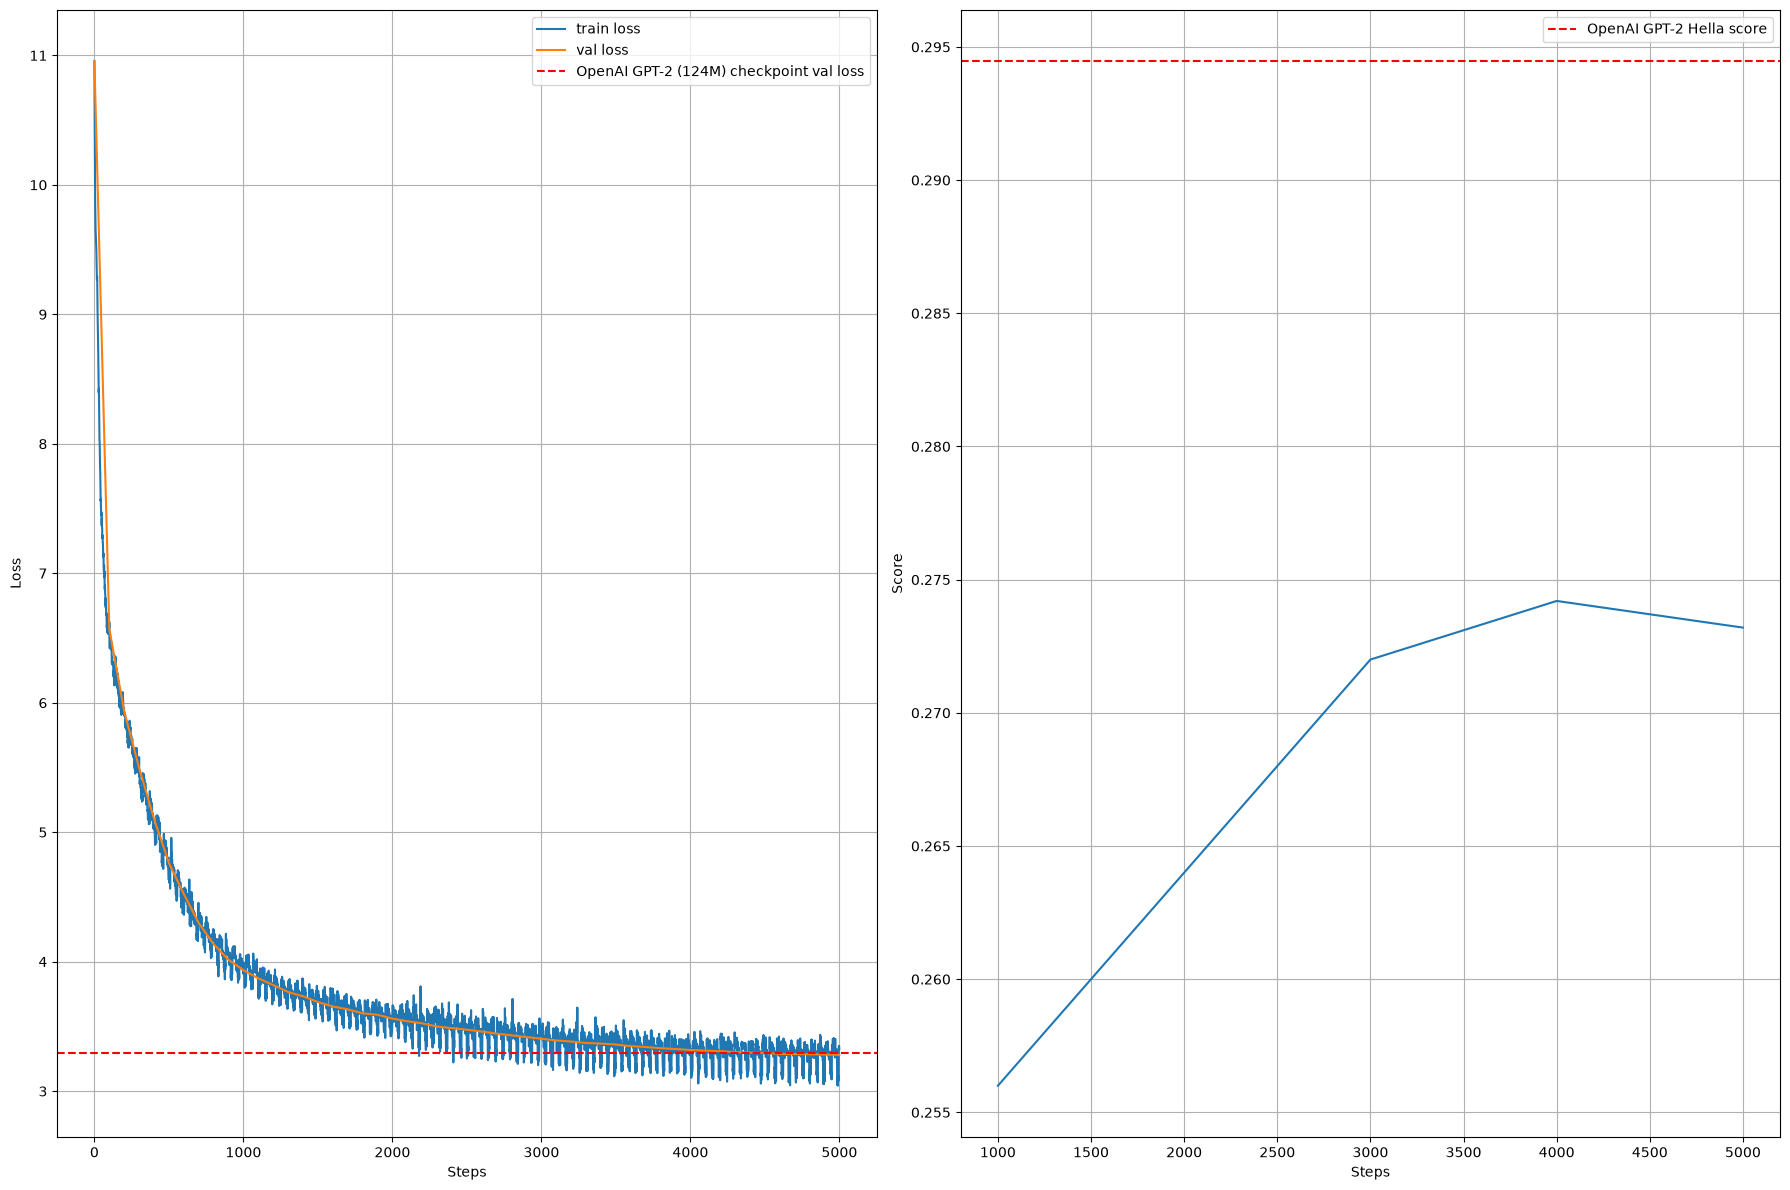

In [29]:
fig, axes = plt.subplots(1, 2, figsize=(18, 12))
axes = axes.flatten()
xs, ys = scores_xy['val']
xs_train, ys_train = scores_xy['train']

axes[0].plot(xs_train, ys_train, label='train loss')
axes[0].plot(xs, ys, label='val loss')
axes[0].axhline(y=loss_baseline, color='r', linestyle='--', label=f"OpenAI GPT-2 ({sz}) checkpoint val loss")

axes[0].legend()
axes[0].grid(True)
axes[0].set_xlabel('Steps')
axes[0].set_ylabel('Loss')

hella_steps, hella_vals = scores_xy['hella']
axes[1].plot(hella_steps, hella_vals)
axes[1].axhline(y=hella2_baseline, color='r', linestyle='--', label=f"OpenAI GPT-2 Hella score")
axes[1].legend()
axes[1].grid(True)
axes[1].set_xlabel('Steps')
axes[1].set_ylabel('Score')

plt.tight_layout()

#### We trained our model on nearly 4 times lesser number of steps, but already achieved good results